- homer : brown (mouth) // blue (pants) // gray (shoes)
- bart : Orange (tshirt) // blue (shorts) // blue (sneaker)
- cant use white because all backgrounds are white and no black because outline is black

### idea:
- analyse all colors by percentage that they appear in image to understand whos features appear more in each image

In [73]:
import cv2 as cv
import numpy as np
import tensorflow as tf
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os

In [68]:
directory = '../Course_Materials/Datasets/homer_bart_1'
files = [os.path.join(directory, f) for f in sorted(os.listdir(directory))]
export = 'mouth,pants,shoes,tshirt,shorts,sneakers,class\n'

In [69]:
show_img = False
features=[]

for image_path in files:
    try:
        original_img = cv.imread(image_path)
        (h,w) = original_img.shape[:2]
    except:
        continue
    img = original_img.copy()
    img_features = []
    mouth = pants = shoes = 0
    tshirt = sneakers = shorts = 0

    image_name = os.path.basename(os.path.normpath(image_path))
    if image_name.startswith('b'):
        class_name = 0
    else:
        class_name = 1

    for height in range(0,h):
        for width in range(0,w):
            blue = img.item(height, width, 0) # BGR[0] = BLUE
            green = img.item(height, width, 1)
            red = img.item(height, width, 2)

            # homer
            if (blue >= 95 and blue <= 185 and green >= 160 and green <= 185 and red >= 175 and red <=200):
                img[height,width] =[0,255,255] # yellow
                mouth +=1
            if height > (h/2):
                if (blue >= 150 and blue <= 180 and green >= 98 and green <= 120 and red >= 0 and red <=90):
                    img[height,width] =[0,255,255] # yellow
                    pants +=1

                if (blue >= 25 and blue <= 45 and green >= 25 and green <= 145 and red >= 25 and red <=45):
                    img[height,width] =[0,255,255] # yellow
                    shoes +=1

            # bart
            if (blue >= 11 and blue <= 22 and green >= 85 and green <= 105 and red >= 240 and red <=255):
                img[height,width] =[255,255,0]
                tshirt +=1

            if (blue >= 125 and blue <= 170 and green >= 0 and green <= 12 and red >= 0 and red <=20):
                    img[height,width] =[255,255,0]
                    shorts +=1
            if height > (h/2):
                if (blue >= 125 and blue <= 45 and green >= 25 and green <= 145 and red >= 25 and red <=45):
                    img[height,width] =[255,255,0]
                    sneakers +=1

# indicates percentage of pixels having this color out of the full image
    mouth = round(mouth/(h * w) * 100)
    pants = round(pants/(h * w) * 100)
    shoes = round(shoes/(h * w) * 100)
    #bart
    tshirt = round(tshirt/(h * w) * 100)
    shorts = round(shorts/(h * w) * 100)
    sneakers = round(sneakers/(h * w) * 100)
####
    img_features.append(mouth)
    img_features.append(pants)
    img_features.append(shoes)
    #bart
    img_features.append(tshirt)
    img_features.append(shorts)
    img_features.append(sneakers)

    img_features.append(class_name)

    features.append(img_features)
    #print(f"Homer mouth: {img_features[0]}% - Homer pants: {img_features[1]}% - Homer shoes: {img_features[2]}%")
    #print(f"Bart tshirt: {img_features[3]}% - Bart Shorts: {img_features[4]}% - Bart Sneakers: {img_features[5]}%")

    f =(",".join([str(item) for item in img_features]))
    export += f + '\n'


    if show_img:
        print(f"Homer mouth: {img_features[0]}% - Homer pants: {img_features[1]}% - Homer shoes: {img_features[2]}%")
        print(f"Bart tshirt: {img_features[3]}% - Bart Shorts: {img_features[4]}% - Bart Sneakers: {img_features[5]}%")
        img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        original_rgb = cv.cvtColor(original_img, cv.COLOR_BGR2RGB)

        fig, im = plt.subplots(1, 2, figsize=(10, 5))
        im[0].axis('off')
        im[0].imshow(original_rgb)
        im[0].set_title("Original")

        im[1].axis('off')
        im[1].imshow(img_rgb)
        im[1].set_title("Mouth Extraction")

        plt.show()

In [70]:
features

[[0, 0, 0, 7, 3, 0, 0],
 [0, 0, 0, 5, 3, 0, 0],
 [0, 0, 0, 5, 5, 0, 0],
 [0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 9, 3, 0, 0],
 [0, 0, 0, 7, 1, 0, 0],
 [0, 0, 0, 10, 4, 0, 0],
 [0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 10, 8, 0, 0],
 [0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 20, 0, 0, 0],
 [0, 0, 0, 6, 6, 0, 0],
 [0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 8, 0, 0, 0],
 [0, 0, 0, 9, 0, 0, 0],
 [0, 0, 0, 11, 5, 0, 0],
 [0, 0, 0, 10, 3, 0, 0],
 [0, 0, 0, 9, 0, 0, 0],
 [0, 0, 0, 5, 4, 0, 0],
 [0, 0, 0, 7, 0, 0, 0],
 [0, 0, 0, 13, 2, 0, 0],
 [0, 0, 0, 12, 7, 0, 0],
 [0, 0, 0, 2, 3, 0, 0],
 [0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 10, 6, 0, 0],
 [0, 0, 0, 4, 6, 0, 0],
 [0, 0, 0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 11, 8, 0, 0],
 [0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 11, 0, 0, 0],
 [0, 0, 0, 6, 3, 0, 0],
 [0, 0, 0, 5, 0, 0, 0],
 [0, 0, 0, 0, 2, 0, 0],
 [0, 0, 0, 17, 1, 0, 0],
 [0, 0, 0, 14, 0, 0, 0],
 [0, 0, 0, 7, 0, 0, 0],
 [0, 0, 0, 7, 2, 0, 0],
 [0, 0, 0, 4, 2, 0, 0],
 [0, 0, 0, 5, 5, 0, 0],
 [0,

In [71]:
export

'mouth,pants,shoes,tshirt,shorts,sneakers,class\n0,0,0,7,3,0,0\n0,0,0,5,3,0,0\n0,0,0,5,5,0,0\n0,0,0,0,0,0,0\n0,0,0,9,3,0,0\n0,0,0,7,1,0,0\n0,0,0,10,4,0,0\n0,0,0,0,0,0,0\n0,0,0,0,0,0,0\n0,0,0,10,8,0,0\n0,0,0,0,0,0,0\n0,0,0,20,0,0,0\n0,0,0,6,6,0,0\n0,0,0,0,0,0,0\n0,0,0,8,0,0,0\n0,0,0,9,0,0,0\n0,0,0,11,5,0,0\n0,0,0,10,3,0,0\n0,0,0,9,0,0,0\n0,0,0,5,4,0,0\n0,0,0,7,0,0,0\n0,0,0,13,2,0,0\n0,0,0,12,7,0,0\n0,0,0,2,3,0,0\n0,0,0,0,0,0,0\n0,0,0,10,6,0,0\n0,0,0,4,6,0,0\n0,0,0,0,0,0,0\n1,0,0,0,0,0,0\n0,0,0,11,8,0,0\n0,0,0,0,0,0,0\n0,0,0,11,0,0,0\n0,0,0,6,3,0,0\n0,0,0,5,0,0,0\n0,0,0,0,2,0,0\n0,0,0,17,1,0,0\n0,0,0,14,0,0,0\n0,0,0,7,0,0,0\n0,0,0,7,2,0,0\n0,0,0,4,2,0,0\n0,0,0,5,5,0,0\n0,0,0,11,0,0,0\n0,0,4,8,0,0,0\n0,0,0,5,7,0,0\n0,0,0,0,19,0,0\n0,0,0,3,2,0,0\n0,0,0,8,2,0,0\n0,0,0,14,6,0,0\n0,0,0,10,4,0,0\n0,0,0,2,6,0,0\n0,0,0,5,3,0,0\n0,0,0,1,2,0,0\n0,0,0,9,0,0,0\n3,0,0,5,4,0,0\n0,0,0,0,0,0,0\n0,0,0,7,0,0,0\n0,0,0,12,0,0,0\n0,0,0,6,0,0,0\n0,0,0,3,2,0,0\n0,0,0,0,1,0,0\n0,0,0,3,1,0,0\n0,0,0,2,3,0,0\n0,0,

In [72]:
with open('features.csv', 'w') as file:
    for l in export:
        file.write(l)
file.closed

True

In [75]:
d = pd.read_csv('features.csv')
d.head(5)

,mouth,pants,shoes,tshirt,shorts,sneakers,class
0,0,0,0,7,3,0,0
1,0,0,0,5,3,0,0
2,0,0,0,5,5,0,0
3,0,0,0,0,0,0,0
4,0,0,0,9,3,0,0


In [77]:
d.info()

<class 'pandas.DataFrame'>
RangeIndex: 269 entries, 0 to 268
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   mouth     269 non-null    int64
 1   pants     269 non-null    int64
 2   shoes     269 non-null    int64
 3   tshirt    269 non-null    int64
 4   shorts    269 non-null    int64
 5   sneakers  269 non-null    int64
 6   class     269 non-null    int64
dtypes: int64(7)
memory usage: 14.8 KB


In [88]:
d['class']

0      0
1      0
2      0
3      0
4      0
      ..
264    1
265    1
266    1
267    1
268    1
Name: class, Length: 269, dtype: int64

<Axes: >

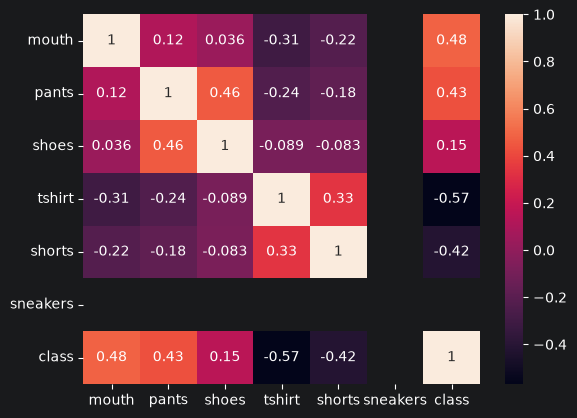

In [81]:
sns.heatmap(d.corr(), annot = True)

In [89]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [91]:
sc = MinMaxScaler()

In [93]:
x = d.drop('class', axis = 1)
x = sc.fit_transform(x)
y = d['class']

In [97]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

((215, 6), (215,))

In [95]:
x_train , x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [99]:
(6 + 2) /2

4.0

In [107]:
# 6 -> 4 -> 4 -> 4 -> 1
minet = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(6,)),
    tf.keras.layers.Dense(units=4, activation='relu'),
    tf.keras.layers.Dense(units=4, activation='relu'),
    tf.keras.layers.Dense(units=4, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])
minet.summary()minet.compile(optimiser='Adam', loss='binary_crossentropy', metrics=['accuracy'])

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73 (292.00 B)

 Trainable params: 73 (292.00 B)

 Non-trainable params: 0 (0.00 B)

In [112]:
minet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
pred = minet.fit(x_train, y_train, epochs=50)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6047 - loss: 0.6599
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6000 - loss: 0.6550 
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6000 - loss: 0.6500 
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6000 - loss: 0.6452 
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6000 - loss: 0.6401 
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6000 - loss: 0.6352 
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6000 - loss: 0.6300 
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6000 - loss: 0.6247 
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6000 - loss: 0.6193 
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6000 - loss: 0.6132 
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6000 - loss: 0.6074 
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6000 - loss: 0.6015 
Ep

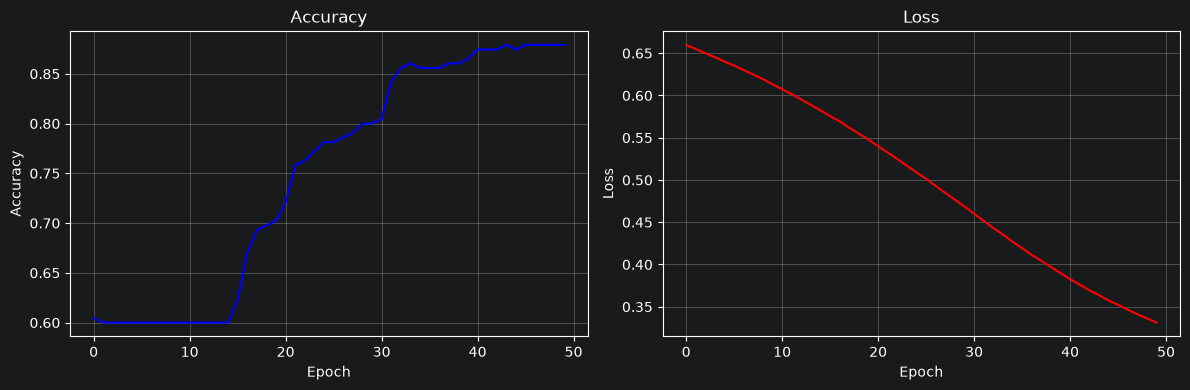

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(pred.history['accuracy'], color='blue', label='Accuracy')
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True)

axes[1].plot(pred.history['loss'], color='red', label='Loss')
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [128]:
from sklearn.metrics import accuracy_score, classification_report

y_probs = minet.predict(x_test)
y_pred = (y_probs > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Bart (0)', 'Homer (1)']))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Accuracy: 0.8518518518518519

Classification Report:
               precision    recall  f1-score   support

    Bart (0)       0.81      0.97      0.88        31
   Homer (1)       0.94      0.70      0.80        23

    accuracy                           0.85        54
   macro avg       0.88      0.83      0.84        54
weighted avg       0.87      0.85      0.85        54



<Axes: >

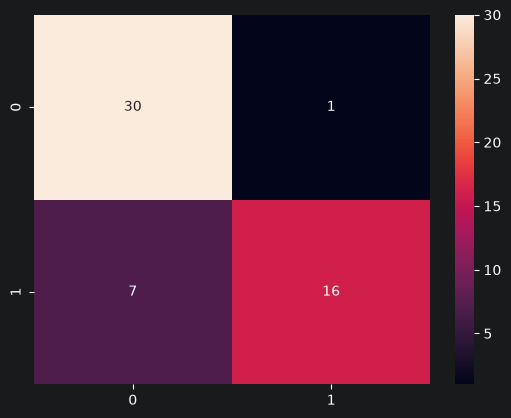

In [129]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)

In [133]:
model_json = minet.to_json()
with open('network2.json', 'w') as json_file:
    json_file.write(model_json)


In [134]:
from keras.models import save_model
network2_saved = save_model(minet, 'weights2.hdf5')
minet.save('network2.keras')